In [2]:
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Report summary

In [28]:
def str2int(s):
    return int(s.replace(",", ""))
    
dat = pd.read_excel("data/NASCseq.xlsx")

In [29]:
# trimming
vs1 = [] # total reads
vs2 = [] # trimmed reads
for run, cell in dat[["Run", "Cell"]].values:
    total_reads = 0
    trimmed_reads = 0
    path = "results/01_prepare/01_cutadapt/%s/%s.log" % (run, cell)
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                if "Total reads processed:" in line or "Total read pairs processed:" in line:
                    total_reads = str2int(line.strip("\n").split()[-1])
                if "Reads written (passing filters):" in line or "Pairs written (passing filters):" in line:
                    trimmed_reads = str2int(line.strip("\n").split()[-2])
    vs1.append(total_reads)
    vs2.append(trimmed_reads)
dat["Total.Reads"] = vs1
dat["Trimmed.Reads"] = vs2
dat["Trimmed.Reads.Ratio"] = dat["Trimmed.Reads"] / dat["Total.Reads"]

In [30]:
# mapping
vs1 = [] # reads
vs2 = [] # uniq mapped
for run, cell in dat[["Run", "Cell"]].values:
    reads = 0
    uniq_mapped = 0
    path = "results/02_mapping/01_star_mapped/%s/%s/%s.Log.final.out" % (run, cell, cell)
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                if "Number of input reads" in line:
                    reads = int(line.strip().split()[-1])
                if "Uniquely mapped reads number" in line:
                    uniq_mapped = int(line.strip().split()[-1])
    vs1.append(reads)
    vs2.append(uniq_mapped)
dat["RiboRNA.Ratio"] = 1 - np.array(vs1) / dat["Trimmed.Reads"]
dat["Clean.Reads"] = vs1
dat["UniqMapped.Reads"] = vs2
dat["UniqMapped.Ratio"] = dat["UniqMapped.Reads"] / dat["Clean.Reads"]

In [31]:
# filtering

vs = []
for run, cell in dat[["Run", "Cell"]].values:
    reads = 0
    path = "results/02_mapping/02_bam_filtered/%s/%s.flagstat" % (run, cell)
    if os.path.exists(path):
        for line in open(path):
            if "in total" in line:
                reads = int(line.split()[0])
                reads = int(reads / 2)
    vs.append(reads)
dat["Filtered.Reads"] = vs

In [32]:
# mark strand

vs1, vs2, vs3, = [], [], []
for run, cell in dat[["Run", "Cell"]].values:
    # mark strand
    uniq, pos, neg = np.nan, np.nan, np.nan
    path = "results/02_mapping/04_marked_strand/%s/%s.tsv" % (run, cell)
    if os.path.exists(path):
        d = pd.read_csv(path, sep="\t", index_col=0)
        vs = d.values[0,:]
        uniq = sum(vs)
        pos, neg = vs[0], vs[1]
    vs1.append(uniq)
    vs2.append(pos)
    vs3.append(neg)
dat["Uniq.Reads"] = vs1
dat["Uniq.Ratio"] = dat["Uniq.Reads"] / dat["Filtered.Reads"]
dat["Forward"], dat["Reverse"] = vs2, vs3
dat["Stranded.Reads"] = dat["Forward"] + dat["Reverse"]
dat["Stranded.Ratio"] = dat["Stranded.Reads"] / dat["Uniq.Reads"]

In [33]:
# new reads
vs = []
for run, cell in dat[["Run", "Cell"]].values:
    path = "results/03_mismatch/02_marked_new_reads/%s/%s.tsv" % (run, cell)
    d = pd.read_csv(path, sep="\t")
    vs.append(d["New"].values[0])
dat["New.Reads"] = vs
dat["New.Reads.Ratio"] = dat["New.Reads"] / dat["Stranded.Reads"]

In [34]:
# mismatch ratio
mtypes = []
for b1 in "ACGT":
    for b2 in "ACGT":
        if b1 != b2:
            mtypes.append("%s%s" % (b1, b2))
rows = []
for run, cell in dat[["Run", "Cell"]].values:
    path = "results/03_mismatch/03_mismatch_ratio/%s/%s.tsv" % (run, cell)
    d = pd.read_csv(path, sep="\t", index_col=0)
    rows.append([d.loc[mt]["Ratio"] for mt in mtypes])
tmp = pd.DataFrame(rows, columns=["%s.Ratio" % mt for mt in mtypes])
for c in tmp.columns:
    dat[c] = tmp[c]

In [35]:
# genes
array = []
for run, cell in dat[["Run", "Cell"]].values:
    path = "results/05_stat/01_detected_genes/%s/%s.tsv" % (run, cell)
    array.append(pd.read_csv(path, sep="\t"))
tmp = pd.concat(array, axis=0, ignore_index=True)
for c in tmp.columns:
   dat["Genes.%s" % c] = tmp[c]

In [36]:
# Pe and Pc
array = []
for run, cell in dat[["Run", "Cell"]].values:
    path = "results/05_stat/03_snr/%s/%s.snr.tsv" % (run, cell)
    array.append(pd.read_csv(path, sep="\t"))
tmp = pd.concat(array, axis=0, ignore_index=True)
tmp = tmp[["Pe", "Pc", "SNR"]]
for c in tmp.columns:
   dat[c] = tmp[c]

In [37]:
m = dat.copy()
m.index = m["Cell"]
m.drop(columns=["Cell"], inplace=True)
m.to_csv("reports/NASCseq_Summary.csv")

# Plot summary

In [22]:
df = pd.read_csv("reports/NASCseq_Summary.csv")
df = df[df["Run"].isin(["20220113_NASCseq", "20220321_NASCseq", "20220418_NASCseq"])]

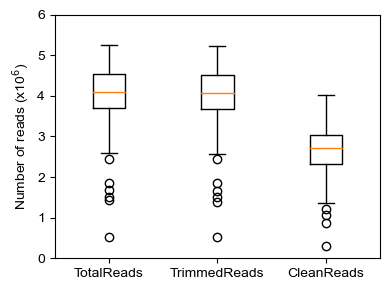

In [23]:
plt.figure(figsize=(4, 3))
plt.boxplot(df[["Total.Reads", "Trimmed.Reads", "Clean.Reads"]]/1e6, showmeans=False)
xs = np.arange(3) + 1
plt.xticks(xs, ["TotalReads", "TrimmedReads", "CleanReads"])
plt.ylabel("Number of reads (x10$^6$)")
plt.ylim(0, 6)
plt.tight_layout()
plt.savefig("figures/reads_number.pdf")

In [24]:
vs = df["Total.Reads"]
print("Total reads:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Trimmed.Reads"]
print("Trimmed reads:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Clean.Reads"]
print("Clean reads:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Trimmed.Reads"]/ df["Total.Reads"]
print("Trimmed ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = df["Clean.Reads"]/ df["Trimmed.Reads"]
print("Clean ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

vs = 1 - df["Clean.Reads"]/ df["Trimmed.Reads"]
print("rRNA ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

Total reads:
Mean: 4031457.2937062937
Std: 745910.7776131205
Trimmed reads:
Mean: 4003310.923076923
Std: 741806.8204065149
Clean reads:
Mean: 2633320.5314685316
Std: 650494.3220101877
Trimmed ratios:
Mean: 0.9928423783157385
Std: 0.002603650476566177
Clean ratios:
Mean: 0.6613211831185072
Std: 0.12453558557902278
rRNA ratios:
Mean: 0.3386788168814929
Std: 0.12453558557902278


In [25]:
vs = df["UniqMapped.Ratio"]
print("Uniquely mapped ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

Uniquely mapped ratios:
Mean: 0.7239023465286464
Std: 0.07463624851844067


In [26]:
vs = df["Stranded.Ratio"]
print("Stranded ratios:")
print("Mean:", np.mean(vs))
print("Std:", np.std(vs))

Stranded ratios:
Mean: 0.9314307777265985
Std: 0.04755638875795311


# Plot comparison

In [3]:
info = pd.read_csv("reports/NASCseq_Summary.csv")
data = dict()
for name in ["GSE128273_NASCseq", "NASCseq"]:
    if name == "GSE128273_NASCseq":
        info1 = info[[run.startswith("GSE") for run in info["Run"]]]
    else:
        info1 = info[[run.startswith("20") for run in info["Run"]]]
    for s4u, d1 in info1.groupby(by="s4U"):
        for time, d2 in d1.groupby(by="Time"):
            data["%s.s4U%duM%dmin" % (name, s4u, time * 60)] = d2

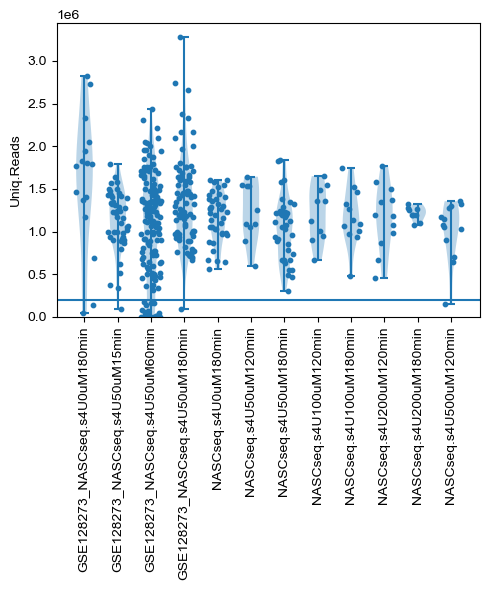

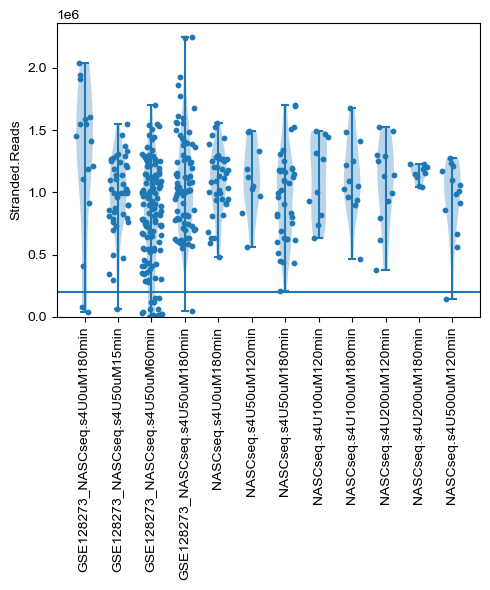

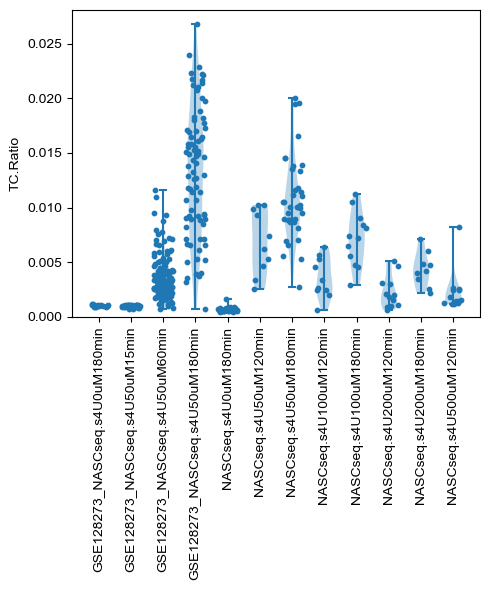

In [57]:
np.random.seed(0)
for k in ["Uniq.Reads", "Stranded.Reads", "TC.Ratio"]:
    xs = np.arange(len(data))
    vs = [d[k] for d in data.values()]
    plt.figure(figsize=(5, 6))
    plt.violinplot(vs, positions=xs)
    for x, ys in zip(xs, vs):
        for y in ys:
            x1 = x + (np.random.random() - 0.5) * 0.6
            plt.scatter(x1, y, marker="o", s=10, color="C0")
    if "Reads" in k:
        plt.axhline(200000)
    plt.xticks(xs, data.keys(), rotation=90)
    plt.ylim(0, None)
    plt.ylabel(k)
    plt.tight_layout()
    plt.show()

In [4]:
for name, d in data.items():
    n1, n2, n3 = len(d), sum(d["Uniq.Reads"] >= 200000), sum(d["Stranded.Reads"] >= 200000)
    print(n1, n2, "%.4f" % (n2/n1), n3, "%.4f" % (n3/n1), name, sep="\t")

16	14	0.8750	14	0.8750	GSE128273_NASCseq.s4U0uM180min
46	45	0.9783	45	0.9783	GSE128273_NASCseq.s4U50uM15min
142	122	0.8592	122	0.8592	GSE128273_NASCseq.s4U50uM60min
80	79	0.9875	79	0.9875	GSE128273_NASCseq.s4U50uM180min
39	39	1.0000	39	1.0000	NASCseq.s4U0uM180min
10	10	1.0000	10	1.0000	NASCseq.s4U50uM120min
38	38	1.0000	38	1.0000	NASCseq.s4U50uM180min
10	10	1.0000	10	1.0000	NASCseq.s4U100uM120min
12	12	1.0000	12	1.0000	NASCseq.s4U100uM180min
12	12	1.0000	12	1.0000	NASCseq.s4U200uM120min
9	9	1.0000	9	1.0000	NASCseq.s4U200uM180min
13	12	0.9231	12	0.9231	NASCseq.s4U500uM120min


# Percentage of recovered reads

In [68]:
info = pd.read_csv("reports/NASCseq_Summary.csv")
info = info[info["Stranded.Reads"] >= 200000]
print(info.shape)

columns = ["Total.Reads", "Trimmed.Reads", "Clean.Reads", "UniqMapped.Reads", "Filtered.Reads", "Uniq.Reads", "Stranded.Reads"]
ticks = ["Total", "Trimmed", "Clean", "Mapped", "Filtered", "RmDup", "Stranded"]
colors = ["C0", "C7", "C7", "C7", "C7", "C7", "C2"]

for i, c in enumerate(columns):
    vs = info[c] * 100 / info["Total.Reads"]
    print(ticks[i], np.mean(vs), np.std(vs), sep="\t")

(402, 44)
Total	100.0	0.0
Trimmed	97.68950781240348	1.702154169756572
Clean	67.578083345215	11.92063299341307
Mapped	51.07101110041169	14.801179493687414
Filtered	45.64287959865417	14.3264668380303
RmDup	36.88826419912656	15.61931415317838
Stranded	30.366161577793118	11.18197192614099


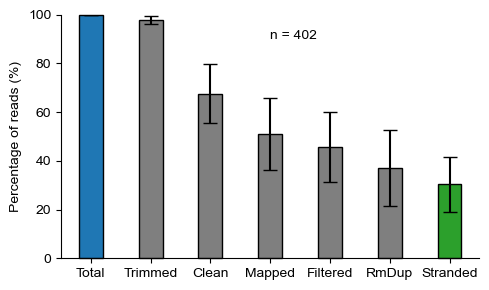

In [69]:
plt.figure(figsize=(5, 3))
for i, c in enumerate(columns):
    vs = info[c] * 100 / info["Total.Reads"]
    plt.bar(i, np.mean(vs), yerr=np.std(vs), width=0.4, capsize=5, color=colors[i], edgecolor="black", lw=1, clip_on=False)
plt.xlim(-0.5, len(columns) - 0.5)
plt.ylim(0, 100)
plt.text(3, 90, "n = %d" % info.shape[0])
plt.xticks(np.arange(len(ticks)), ticks)
plt.ylabel("Percentage of reads (%)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/percentage_of_reads.pdf")

In [70]:
info = pd.read_csv("reports/NASCseq_Summary.csv")
info = info[info["Stranded.Reads"] >= 200000]
print(info.shape)

array = []
for cell in info["Cell"]:
    array.append(pd.read_csv("results/02_mapping/04_marked_strand/%s/%s.tsv" % (cell.split(".")[0], cell), sep="\t", index_col=0))
m = pd.concat(array)
m = m.divide(m.sum(axis=1), axis=0) * 100

means = m.mean(axis=0)
stds = m.std(axis=0)
names = ["Forward", "Reverse", "Ambiguous", "Unknown"]
labels = []
for name, mean, std in zip(names, means, stds):
    print(name, mean, std, sep="\t")
    labels.append("%s (%.2f%% ± %.2f%%)" % (name, mean, std))
colors = ["C0", "C1", "C3", "C7"]

(402, 44)
Forward	43.03237668301291	4.9595481522318705
Reverse	41.30834856658776	5.132380643928265
Ambiguous	3.388104539253387	0.7403567394247699
Unknown	12.27117021114595	9.425323566953795


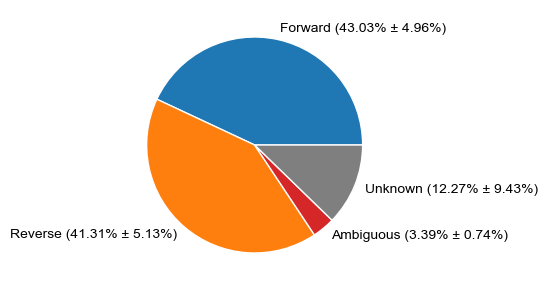

In [71]:
plt.figure(figsize=(6, 3))
plt.pie(means, labels=labels, wedgeprops=dict(edgecolor="white"), colors=colors)
plt.tight_layout()
plt.savefig("figures/pie_of_stranded_reads.pdf")

In [72]:
info = pd.read_csv("reports/NASCseq_Summary.csv")
print(info.shape)
vs1 = info[[not cell.startswith("20") for cell in info["Cell"]]]["Stranded.Reads"]/1e6
vs2 = info[[cell.startswith("20") for cell in info["Cell"]]]["Stranded.Reads"]/1e6
print("Median of GSE128273_NASCseq:", np.median(vs1))
print("Median of NASCseq:", np.median(vs2))

(427, 44)
Median of GSE128273_NASCseq: 0.99429
Median of NASCseq: 1.089715


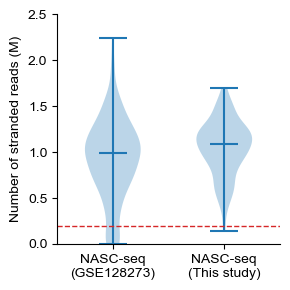

In [73]:
plt.figure(figsize=(3, 3))
plt.violinplot([vs1, vs2], showmedians=True)
plt.axhline(0.2, lw=1, ls="--", color="C3")
plt.xlim(0.5, 2.5)
plt.ylim(0, 2.5)
plt.xticks([1, 2], ["NASC-seq\n(GSE128273)", "NASC-seq\n(This study)"])
plt.ylabel("Number of stranded reads (M)")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("figures/number_of_stranded_reads.pdf")